# Create a wavelength lookup table for BIFROST

This notebook shows how to create a wavelength lookup table for frame unwrapping at BIFROST.

In [1]:
from ess.reduce import nexus
import sciline
import scipp as sc
from scippneutron.conversion.graph import beamline as beamline_graph
import scippnexus as snx
from ess.reduce.nexus.types import AnyRun, RawChoppers, DiskChoppers, Position
from ess.reduce.unwrap import (
    LtotalRange,
    NumberOfSimulatedNeutrons,
    LookupTableWorkflow,
)
from scippneutron.chopper import DiskChopper

from ess.bifrost import BifrostSimulationWorkflow
from ess.bifrost.data import simulated_elastic_incoherent_with_phonon
from ess.spectroscopy.types import *

## Load and process beamline parameters

First, load all required beamline parameters from an input NeXus file.
We only need to know the geometry up to the sample which is the same for all banks, so choosing a single detector is enough.

In [2]:
bifrost_workflow = BifrostSimulationWorkflow()
bifrost_workflow[Filename[SampleRun]] = simulated_elastic_incoherent_with_phonon()

M = nexus.types.EmptyMonitor[SampleRun, NormalizationMonitor]
C = RawChoppers[SampleRun]
SOURCE = Position[snx.NXsource, SampleRun]
SAMPLE = Position[snx.NXsample, SampleRun]
choppers, monitor, sample_position, source_position = bifrost_workflow.compute((C, M, SAMPLE, SOURCE)).values()
detector = sciline.compute_mapped(bifrost_workflow, EmptyDetector[SampleRun])[0]

Compute the required distance range to include the monitor and all detectors.
Strictly speaking, we only need the range from the chosen monitor up to the Bragg peak monitor as we unwrap the regular detector data at the sample position.
But this implementation is simpler and should work fine.

In [3]:
graph = {
    **beamline_graph.beamline(scatter=True),
    'sample_position': lambda: sample_position,
    'source_position': lambda: source_position,
}

l_monitor = sc.norm(source_position - monitor.coords['position'])
l_min = l_monitor
l_max = detector.transform_coords('Ltotal', graph=graph).coords['Ltotal'].max()

The choppers in the simulated file need to be processed before they can be used for computing a lookup table.
The following works for the specific simulation but is **not** usable in general.

In [4]:
def extract_chopper_plateau(chopper):
    processed = chopper.copy()
    # These are constant in the simulated data.
    processed['rotation_speed'] = processed['rotation_speed'].data.mean()
    processed['phase'] = processed['phase'].data.mean()
    # Guessing here as this is not stored in the file.
    processed['beam_position'] = sc.scalar(0.0, unit='deg')

    # FIXME Get rid of this bad hack if/when McStas' DiskChopper is fixed
    #      Currently, it sets a delay-time by `delta = 2 * pi * phase/|frequency|`
    #      But it should set `delta = 2 * pi * phase / frequency`
    #      So phases reported here have the wrong sign if frequency < 0
    processed['phase'] = -processed['phase'] if processed['rotation_speed'].value < 0 else processed['phase']

    return DiskChopper.from_nexus(processed)


disk_choppers = choppers.apply(extract_chopper_plateau)

## Compute the lookup table

Construct a lookup table workflow:

In [5]:
workflow = LookupTableWorkflow()
workflow[DiskChoppers[AnyRun]] = disk_choppers
workflow[LtotalRange[AnyRun, snx.NXdetector]] = (l_min, l_max)
workflow[Position[snx.NXsource, AnyRun]] = source_position

# Increase this number for more reliable results:
workflow[NumberOfSimulatedNeutrons] = 1_000_000

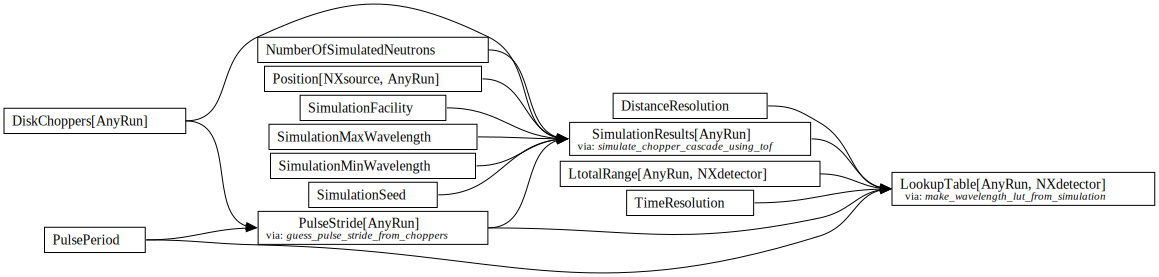

In [6]:
workflow.visualize(LookupTable[AnyRun, snx.NXdetector], graph_attr={"rankdir": "LR"})

Compute a lookup table:

In [7]:
table = workflow.compute(LookupTable[AnyRun, snx.NXdetector])
table

LookupTable(array=<scipp.DataArray>
Dimensions: Sizes[distance:23, event_time_offset:287, ]
Coordinates:
* distance                  float64              [m]  (distance)  [161.236, 161.336, ..., 163.336, 163.436]
* event_time_offset         float64            [µs]  (event_time_offset)  [0, 249.75, ..., 71178.8, 71428.6]
Data:
                            float64             [Å]  (distance, event_time_offset)  [3.47076, 3.47614, ..., 3.41492, 3.42176]  [3.93683e-06, 5.33612e-06, ..., 4.19663e-06, 3.94419e-06]

, pulse_period=<scipp.Variable> ()    float64            [µs]  71428.6, pulse_stride=1, distance_resolution=<scipp.Variable> ()    float64              [m]  0.1, time_resolution=<scipp.Variable> ()    float64            [µs]  249.75, choppers=DataGroup(sizes={'dim_0': 1}, keys=[
    bandwidth_chopper_1: DataGroup(8, {'dim_0': 1}),
    bandwidth_chopper_2: DataGroup(8, {'dim_0': 1}),
    frame_overlap_chopper_1: DataGroup(8, {'dim_0': 1}),
    frame_overlap_chopper_2: DataGroup(8, {

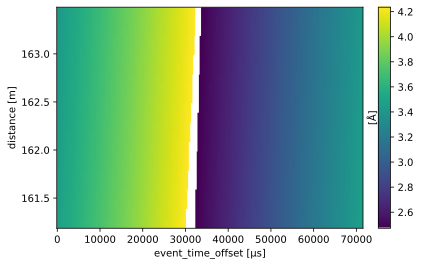

In [8]:
table.plot()

## Save to file

In [9]:
table.save_hdf5('BIFROST-simulation-lookup-table.h5')